# [1교시]

cursor : db에 접속해서 연결하여 query편집창을 연다

query 구문:
- ''' '''으로 담는다.

# 기존테이블 삭제(초기화)
db = ShopDB(**DB_CONFIG)
db.connect()
tables = ['order_details','orders','customers','prodcuts']
for table in tables:
    db.execute(f'drop table if exists {table}')

In [ ]:
# mysql 환경 만들기
%conda install mysql-connector-python python-dotenv pandas

import mysql.connector as mc
from mysql.connector import Error
from datetime import datetime, timedelta
import os
from dotenv import load_dotenv
import pandas as pd

In [ ]:
# 가상환경이 잘 불러와지는지 확인
load_dotenv()

In [ ]:
# 비밀번호 확인
os.getenv('DB_PASSWORD')

In [ ]:
# DB정보 확인
DB_CONFIG = {
    'host' : os.getenv('DB_HOST'),
    'user' : os.getenv('DB_USER'),
    'password' : os.getenv('DB_PASSWORD'),
    'database' : os.getenv('DB_NAME'),
    'port' : os.getenv('DB_PORT')
}

DB_CONFIG

In [ ]:
class ShopDB:
    '''
    쇼핑몰 데이터베이스 관리 클래스
    '''
    def __init__(self, host, user, password, database, port=3306):
        self.host = host
        self.user = user
        self.password = password
        self.database = database
        self.port = port
    def connect(self):
        '''연결'''
        try:
            self.conn = mc.connect(host=self.host, user=self.user,
                        password=self.password, database=self.database,
                        port=self.port)
            self.cursor = self.conn.cursor()
            self.cursor.execute(f'use {self.database}')
            return True
        except Error as e:
            print(f'데이터베이스 에러 : {e}')
            return False
    def close(self):
        '''연결종료'''
        if self.cursor:
            self.cursor.close()
        if self.conn and self.conn.is_connected():
            self.conn.close()
        print('연결 종료')
    def execute(self, query, params = None):
        '''쿼리실행'''
        try:
            if params:
                self.cursor.execute(query, params)
            else:
                self.cursor.execute(query)
        except Error as e:
            print(f'쿼리 에러 : {e}')
    def fetchall(self):
        return self.cursor.fetchall()
    def fetchone(self):
        return self.cursor.fetchone()
    def query_to_dataframe(self, query, param=None):
        '''쿼리결과를 pandas dataframe으로 변환'''
        self.execute(query,params)
        columns = [desc[0] for desc in self.cursor.description]
        data = self.cursor.fetchall()
        return pd.DataFrame(data, columns=columns)

In [ ]:
sh = ShopDB(**DB_CONFIG)
sh.connect()

In [ ]:
# sh.close()

# [2교시]

# 테이블 생성 - 숙제

(실습은 테이블 수동생성)

In [ ]:
# 기존테이블 삭제(초기화)
# db = ShopDB(**DB_CONFIG)
# db.connect()
# tables = ['order_detail','orders','customers','products']
# for table in tables:
#     db.execute(f'drop table if exists {table}')    

# # customer 테이블 생성
# with open('query.txt', 'r', encoding='utf-8') as f:    
#    print(f.read())

#text, join이든 vscode로 table만들기 숙제

(customer 테이블 생성)
- with open('query.txt', 'r', encoding='utf=8') as f:
-    print(f.read())

# 데이터 삽입

In [ ]:
db = ShopDB(**DB_CONFIG)
db.connect()

customers_data = [
    ('김철수', 'kim@email.com', 'Gold', 5000, '2023-01-15'),
    ('이영희', 'lee@email.com', 'Silver', 3000, '2023-03-20'),
    ('박민수', 'park@email.com', 'Bronze', 1000, '2023-06-10'),
    ('최지은', 'choi@email.com', 'Gold', 6000, '2023-02-05'),
    ('정수진', 'jung@email.com', 'Silver', 2500, '2023-04-18'),
    ('강동원', 'kang@email.com', 'Bronze', 500, '2024-01-20'),
    ('윤서연', 'yoon@email.com', 'Silver', 3500, '2023-05-12'),
    ('임하늘', 'lim@email.com', 'Bronze', 800, '2024-02-01'),
    ('송민호', 'song@email.com', 'Gold', 7000, '2023-01-28'),
    ('한지민', 'han@email.com', 'Bronze', 1200, '2023-07-15'),
]
query = '''insert into customers (name, email, grade,
    point,join_date) values(%s,%s,%s,%s,%s)'''
for customer in customers_data:
    db.execute(query,customer)
db.commit()
db.close()


In [ ]:
db = ShopDB(**DB_CONFIG)
db.connect()

products_data = [
    ('노트북', '전자기기', 1200000, 15),
    ('무선마우스', '전자기기', 35000, 50),
    ('키보드', '전자기기', 89000, 30),
    ('모니터', '전자기기', 350000, 20),
    ('청바지', '의류', 59000, 100),
    ('티셔츠', '의류', 25000, 150),
    ('운동화', '의류', 89000, 80),
    ('백팩', '가방', 45000, 40),
    ('텀블러', '생활용품', 15000, 200),
    ('책상스탠드', '생활용품', 28000, 60),
] 
query = '''insert into products (product_name, category,
    price, stock) values(%s,%s,%s,%s)'''
for data in products_data:
    db.execute(query, data)
db.commit()
db.close()

In [ ]:
db = ShopDB(**DB_CONFIG)
db.connect()

orders_data = [
    (1, '2024-02-15 10:30:00', 1235000, 'Completed'),
    (1, '2024-02-20 14:20:00', 89000, 'Completed'),
    (2, '2024-02-16 09:15:00', 375000, 'Completed'),
    (3, '2024-02-17 16:45:00', 143000, 'Completed'),
    (4, '2024-02-18 11:00:00', 1550000, 'Completed'),
    (5, '2024-02-19 13:30:00', 84000, 'Completed'),
    (6, '2024-02-21 10:00:00', 59000, 'Pending'),
    (7, '2024-02-22 15:20:00', 254000, 'Completed'),
    (8, '2024-02-23 12:10:00', 45000, 'Cancelled'),
    (9, '2024-02-24 14:50:00', 1289000, 'Completed'),
]
query = '''insert into orders (customer_id, order_date, total_amount,
    status) values(%s,%s,%s,%s)'''
for data in orders_data:
    db.execute(query,data)
db.commit()
db.close()


In [ ]:
db = ShopDB(**DB_CONFIG)
db.connect()

order_details_data = [
    (1, 1, 1, 1200000, 1200000),
    (1, 2, 1, 35000, 35000),
    (2, 3, 1, 89000, 89000),
    (3, 4, 1, 350000, 350000),
    (3, 5, 1, 25000, 25000),
    (4, 5, 2, 59000, 118000),
    (4, 6, 1, 25000, 25000),
    (5, 1, 1, 1200000, 1200000),
    (5, 4, 1, 350000, 350000),
    (6, 7, 1, 89000, 89000),
    (7, 5, 1, 59000, 59000),
    (8, 2, 3, 35000, 105000),
    (8, 3, 1, 89000, 89000),
    (8, 9, 2, 15000, 30000),
    (8, 10, 1, 28000, 28000),
    (9, 8, 1, 45000, 45000),
    (10, 1, 1, 1200000, 1200000),
    (10, 3, 1, 89000, 89000),
]
query = '''insert into order_details (order_id, product_id, quantity,
    unit_price,subtotal) values(%s,%s,%s,%s,%s)'''
for data in order_details_data:
    db.execute(query,data)
db.commit()
db.close()


# 데이터조회(select)

In [ ]:
db = ShopDB(**DB_CONFIG)
db.connect()

df_customers = db.query_to_dataframe('select * from customers')

db.close()

In [ ]:
df_customers

# [3교시]

shop_db_join_practice.ipynb 복습!!

# [4교시]

shop_db_manager.py
app.py

In [ ]:
"abc 123".startwidth('abc')

# [5교시]

In [ ]:
def main():
    '''메인어플리케이션'''
    # == 페이지 설정 ==
    st.set_page_config(
        page_title='쇼핑몰 데이터 대시보드',
        layout='wide'
    )
    # 타이틀
    st.title('쇼핌몰 데이터 대시보드')
    st.markdown('--')

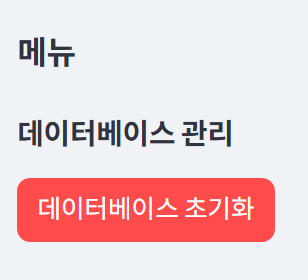

더미버튼, 아직 적용이 안되어서 눌러도 적용 x

에러를 고쳐가는 과정에서 숙련, 에러의 이유(고치는과정, 결과, 분석 및 파악)를 거쳐야 전문가가 될 수 있음

# [6교시]

shop_db_manager.py & app2.py => 기본 base

plotly_chart(fig) => 파이 객체

DB - MySQL

query - DB

potly - Library

py <-> db

# [7교시]

poltly_practice.ipynb

# [8교시]

공모전 또는 사업 할 때
- 벤치마킹 必

csv ==> Data
배포, 공유가 가능하다!

수집한 데이터 관리
- server => data Export [내보내기]
- server => data Import
[가져오기]


데이터 공유 [계정 추가해서 같이사용]
- server => users and privileges => login 입력 => administrative roles 권한 부여

create database shop_db;

select * from customers;

단위프로젝트 참고하면 좋을 자료 : - https://www.data.go.kr/data/15071233/openapi.do
- 역할 분류
- 코드 리뷰

내일 수업은 정적 크롤링, 깃허브 환경 설치